In [1]:
import zipfile
import datetime
import string
import math
import os

import tqdm
import matplotlib.pyplot as plt
import tensorflow as tf
import sklearn.model_selection

import keras_ocr
import tensorflow as tf 
from utils import get_text_generator

In [2]:
## Generating synthetic data
assert tf.test.is_gpu_available(), 'No GPU is available.'

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.


2025-03-19 10:12:28.419822: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2025-03-19 10:12:28.419875: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2025-03-19 10:12:28.419882: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.00 GB
2025-03-19 10:12:28.419960: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-03-19 10:12:28.420244: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [ ]:
data_dir = '.'
alphabet = string.digits + string.ascii_letters + '+-×±Φφ. '
fonts = keras_ocr.data_generation.get_fonts(
    alphabet=alphabet,
    cache_dir=data_dir
)
myfonts = [
    './myfonts/fangsong_GB2312.ttf', 
    './myfonts/GenShinGothic-Medium.ttf', 
    './myfonts/GenShinGothic-Monospace-Normal.ttf', 
    './myfonts/GenShinGothic-Normal.ttf', 
    './myfonts/GenShinGothic-P-Normal.ttf', 
    './myfonts/GenShinGothic-Regular.ttf', 
    './myfonts/kaiti_GB2312.ttf', 
    './myfonts/msyh.ttf', 
    './myfonts/simhei.ttf', 
    './myfonts/songti.ttf'
]
for myfont in myfonts:
    fonts.append(myfont)

backgrounds = keras_ocr.data_generation.get_backgrounds(cache_dir=data_dir)

Looking for ./fonts.zip


Filtering fonts.: 100%|██████████| 2746/2746 [00:03<00:00, 735.48it/s]


Looking for ./backgrounds.zip


In [6]:
fonts

['./fonts/ubuntumono/UbuntuMono-BoldItalic.ttf',
 './fonts/ubuntumono/UbuntuMono-Bold.ttf',
 './fonts/ubuntumono/UbuntuMono-Italic.ttf',
 './fonts/ubuntumono/UbuntuMono-Regular.ttf',
 './fonts/seoulhangang/SeoulHangang-Light.ttf',
 './fonts/seoulhangang/SeoulHangang-Bold.ttf',
 './fonts/seoulhangang/SeoulHangang-ExtraBold.ttf',
 './fonts/seoulhangang/SeoulHangang-Medium.ttf',
 './fonts/opensanscondensed/OpenSansCondensed-Bold.ttf',
 './fonts/opensanscondensed/OpenSansCondensed-LightItalic.ttf',
 './fonts/opensanscondensed/OpenSansCondensed-Light.ttf',
 './fonts/mplus1p/Mplus1p-ExtraBold.ttf',
 './fonts/mplus1p/Mplus1p-Light.ttf',
 './fonts/mplus1p/Mplus1p-Bold.ttf',
 './fonts/mplus1p/Mplus1p-Black.ttf',
 './fonts/mplus1p/Mplus1p-Medium.ttf',
 './fonts/mplus1p/Mplus1p-Regular.ttf',
 './fonts/tinos/Tinos-Regular.ttf',
 './fonts/tinos/Tinos-Italic.ttf',
 './fonts/tinos/Tinos-Bold.ttf',
 './fonts/tinos/Tinos-BoldItalic.ttf',
 './fonts/jejuhallasan/JejuHallasan-Regular.ttf',
 './fonts/tuffy

In [4]:
# text_generator = keras_ocr.data_generation.get_text_generator(alphabet=alphabet)
text_generator = get_text_generator(alphabet=alphabet)
print('The first generated text is:', next(text_generator))

The first generated text is: 9.3×Φ5.8


In [5]:
def get_train_val_test_split(arr):
    train, valtest = sklearn.model_selection.train_test_split(arr, train_size=0.8, random_state=42)
    val, test = sklearn.model_selection.train_test_split(valtest, train_size=0.5, random_state=42)
    return train, val, test

In [6]:
background_splits = get_train_val_test_split(backgrounds)
font_splits = get_train_val_test_split(fonts)

In [7]:
image_generators = [
    keras_ocr.data_generation.get_image_generator(
        height=640,
        width=640,
        text_generator=text_generator,
        font_groups={
            alphabet: current_fonts
        },
        backgrounds=current_backgrounds,
        font_size=(60, 120),
        margin=50,
        rotationX=(-0.05, 0.05),
        rotationY=(-0.05, 0.05),
        rotationZ=(-15, 15)
    )  for current_fonts, current_backgrounds in zip(
        font_splits,
        background_splits
    )
]

The first generated validation image (below) contains: Φ
2.65


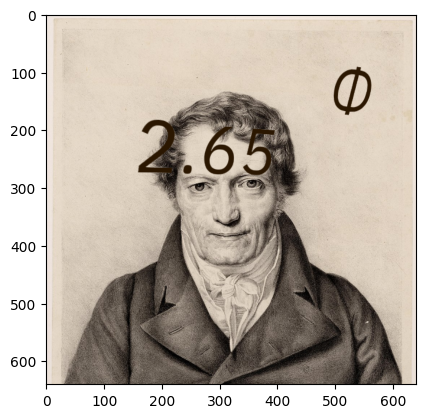

In [8]:
image, lines = next(image_generators[1])
text = keras_ocr.data_generation.convert_lines_to_paragraph(lines)
print('The first generated validation image (below) contains:', text)
plt.imshow(image)

In [17]:
detector = keras_ocr.detection.Detector(weights='clovaai_general')

Looking for /Users/ywu/.keras-ocr/craft_mlt_25k.h5


2025-03-19 09:47:49.564462: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-03-19 09:47:49.564480: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [18]:
## Train the detector
detector_batch_size = 1
detector_basepath = os.path.join(data_dir, f'detector_{datetime.datetime.now().isoformat()}')
detection_train_generator, detection_val_generator, detection_test_generator = [
    detector.get_batch_generator(
        image_generator=image_generator,
        batch_size=detector_batch_size
    ) for image_generator in image_generators
]
detector.model.fit(
    detection_train_generator,
    steps_per_epoch=math.ceil(len(background_splits[0]) / detector_batch_size),
    epochs=10,
    workers=0,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(restore_best_weights=True, patience=5),
        tf.keras.callbacks.CSVLogger(f'{detector_basepath}.csv'),
        tf.keras.callbacks.ModelCheckpoint(filepath=f'{detector_basepath}.h5')
    ],
    validation_data=detection_val_generator,
    validation_steps=math.ceil(len(background_splits[1]) / detector_batch_size),
    batch_size=detector_batch_size
)

Epoch 1/10


2025-03-19 09:48:16.211816: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


238/827 [=======>......................] - ETA: 2:36 - loss: 0.0028

2025-03-19 09:49:19.967925: W tensorflow/core/framework/op_kernel.cc:1816] UNKNOWN: AttributeError: 'list' object has no attribute 'read'
Traceback (most recent call last):

  File "/opt/miniconda3/envs/ocr/lib/python3.10/site-packages/tensorflow/python/ops/script_ops.py", line 268, in __call__
    ret = func(*args)

  File "/opt/miniconda3/envs/ocr/lib/python3.10/site-packages/tensorflow/python/autograph/impl/api.py", line 643, in wrapper
    return func(*args, **kwargs)

  File "/opt/miniconda3/envs/ocr/lib/python3.10/site-packages/tensorflow/python/data/ops/from_generator_op.py", line 198, in generator_py_func
    values = next(generator_state.get_iterator(iterator_id))

  File "/opt/miniconda3/envs/ocr/lib/python3.10/site-packages/keras/src/engine/data_adapter.py", line 917, in wrapped_generator
    for data in generator_fn():

  File "/opt/miniconda3/envs/ocr/lib/python3.10/site-packages/keras_ocr/detection.py", line 722, in get_batch_generator
    batch = [next(image_generator) f

239/827 [=======>......................] - ETA: 2:35 - loss: 0.0028

2025-03-19 09:49:20.222885: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous recv item cancelled. Key hash: 15537765325768376540
2025-03-19 09:49:20.222898: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous recv item cancelled. Key hash: 8085866822818812635
2025-03-19 09:49:20.222909: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous recv item cancelled. Key hash: 4923350766943592848
2025-03-19 09:49:20.222918: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous recv item cancelled. Key hash: 6624209900287226755
2025-03-19 09:49:20.222929: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous recv item cancelled. Key hash: 2677568353938120160
2025-03-19 09:49:20.222942: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous recv item cancelled. Key hash: 10262060264614602282
2025-03-19 09:49:20.222951: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous recv i

UnknownError: Graph execution error:

2 root error(s) found.
  (0) UNKNOWN:  AttributeError: 'list' object has no attribute 'read'
Traceback (most recent call last):

  File "/opt/miniconda3/envs/ocr/lib/python3.10/site-packages/tensorflow/python/ops/script_ops.py", line 268, in __call__
    ret = func(*args)

  File "/opt/miniconda3/envs/ocr/lib/python3.10/site-packages/tensorflow/python/autograph/impl/api.py", line 643, in wrapper
    return func(*args, **kwargs)

  File "/opt/miniconda3/envs/ocr/lib/python3.10/site-packages/tensorflow/python/data/ops/from_generator_op.py", line 198, in generator_py_func
    values = next(generator_state.get_iterator(iterator_id))

  File "/opt/miniconda3/envs/ocr/lib/python3.10/site-packages/keras/src/engine/data_adapter.py", line 917, in wrapped_generator
    for data in generator_fn():

  File "/opt/miniconda3/envs/ocr/lib/python3.10/site-packages/keras_ocr/detection.py", line 722, in get_batch_generator
    batch = [next(image_generator) for n in

In [9]:
# TensorFlow 2.x compatibility
# 这两行代码一定要在model.compile()之前执行 
tf.compat.v1.disable_eager_execution()
tf.compat.v1.experimental.output_all_intermediates(True)
# recognizer_alphabet = ''.join(sorted(set(alphabet)))
recognizer_alphabet = alphabet
recognizer = keras_ocr.recognition.Recognizer(
    alphabet=recognizer_alphabet,
    weights='kurapan'
)
recognizer.compile()
for layer in recognizer.backbone.layers:
    layer.trainable = False

Instructions for updating:
Colocations handled automatically by placer.


2025-03-19 10:13:25.439347: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-03-19 10:13:25.439364: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2025-03-19 10:13:25.518084: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-03-19 10:13:25.518100: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL,

Provided alphabet does not match pretrained alphabet. Using backbone weights only.
Looking for /Users/ywu/.keras-ocr/crnn_kurapan_notop.h5


2025-03-19 10:13:25.943818: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-03-19 10:13:25.954974: W tensorflow/c/c_api.cc:304] Operation '{name:'lstm_11/lstm_cell/recurrent_kernel/Assign' id:1353 op device:{requested: '', assigned: ''} def:{{{node lstm_11/lstm_cell/recurrent_kernel/Assign}} = AssignVariableOp[_has_manual_control_dependencies=true, dtype=DT_FLOAT, validate_shape=false](lstm_11/lstm_cell/recurrent_kernel, lstm_11/lstm_cell/recurrent_kernel/Initializer/mul_1)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.
2025-03-19 10:13:25.995382: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-03-19 10:13:26.043175: I tensorflow/core/grappler/optimizers/cus

In [10]:
max_length = 10
recognition_image_generators = [
    keras_ocr.data_generation.convert_image_generator_to_recognizer_input(
        image_generator=image_generator,
        max_string_length=min(recognizer.training_model.input_shape[1][1], max_length),
        target_width=recognizer.model.input_shape[2],
        target_height=recognizer.model.input_shape[1],
        margin=1
    ) for image_generator in image_generators
]

This image contains: q


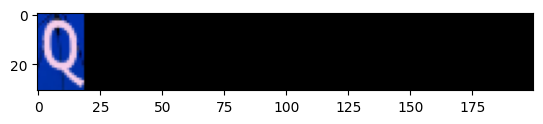

In [11]:
# See what the first validation image for recognition training looks like.
image, text = next(recognition_image_generators[1])
print('This image contains:', text)
plt.imshow(image)

In [13]:
recognition_batch_size = 8
recognizer_basepath = os.path.join(data_dir, f'recognizer_{datetime.datetime.now().isoformat()}')
recognition_train_generator, recognition_val_generator, recognition_test_generator = [
    recognizer.get_batch_generator(
    image_generator=image_generator,
    batch_size=recognition_batch_size,
    lowercase=False
    ) for image_generator in recognition_image_generators
]

In [14]:
recognizer.training_model.fit(
    recognition_train_generator,
    epochs=10,
    steps_per_epoch=math.ceil(len(background_splits[0]) / recognition_batch_size),
    callbacks=[
        tf.keras.callbacks.EarlyStopping(restore_best_weights=True, patience=25),
        tf.keras.callbacks.CSVLogger(f'{recognizer_basepath}.csv', append=True),
        tf.keras.callbacks.ModelCheckpoint(filepath=f'{recognizer_basepath}.h5')
    ],
    validation_data=recognition_val_generator,
    validation_steps=math.ceil(len(background_splits[1]) / recognition_batch_size),
    workers=0,
    # batch_size=recognition_batch_size
)

Epoch 1/10


2025-03-19 10:13:58.559431: W tensorflow/c/c_api.cc:304] Operation '{name:'bn_7/AssignMovingAvg_1/AssignSubVariableOp' id:320 op device:{requested: '', assigned: ''} def:{{{node bn_7/AssignMovingAvg_1/AssignSubVariableOp}} = AssignSubVariableOp[_class=["loc:@bn_7/moving_variance"], _has_manual_control_dependencies=true, dtype=DT_FLOAT](bn_7/moving_variance, bn_7/AssignMovingAvg_1/mul)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.
2025-03-19 10:13:58.633114: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-03-19 10:13:58.654823: W tensorflow/c/c_api.cc:304] Operation '{name:'training/RMSprop/lstm_10/lstm_cell/recurrent_kernel/rms/Assign' id:3356 op device:{requested: '', assigned: ''} def:{{{node training/RMSprop/lstm_10/lstm_cell/recurrent_

 59/104 [================>.............] - ETA: 4:13 - batch: 29.0000 - size: 8.0000 - loss: 16.8033

AttributeError: 'list' object has no attribute 'read'

In [ ]:
## Use the models for inference
pipeline = keras_ocr.pipeline.Pipeline(detector=detector, recognizer=recognizer)
image, lines = next(image_generators[0])
predictions = pipeline.recognize(images=[image])[0]
drawn = keras_ocr.tools.drawBoxes(
    image=image, boxes=predictions, boxes_format='predictions'
)
print(
    'Actual:', '\n'.join([' '.join([character for _, character in line]) for line in lines]),
    'Predicted:', [text for text, box in predictions]
)
plt.imshow(drawn)